# Envelope detectors & gain-reduction reconstruction — Diff-SSL-G-Comp

This notebook studies how different **level / envelope detectors** estimate the
time-varying **gain reduction (GR)** of two compressors — the analog **SSL
G-Bus** and an Ableton **"Digital"** ideal compressor — on the *same* audio cut
from the **Diff-SSL-G-Comp** dataset.

A compressor's output is, to first order, the dry input multiplied by a
time-varying gain:

$$ \text{wet}(t) \approx \text{dry}(t)\cdot g(t), \qquad g(t)=10^{\,GR(t)/20}. $$

So if we can estimate a level envelope for both signals, we can estimate the GR
and **reconstruct** the wet signal as `dry * gain`. The residual
`target − reconstruction` is everything a smooth gain on the dry signal *cannot*
explain (mostly the compressor's nonlinearity / added harmonics).

**Detectors compared**

| Detector | Window | Character |
|---|---|---|
| Hilbert | none (instantaneous) | magnitude of the analytic signal |
| RMS, W = 64 | ~1.5 ms | fast / local moving RMS |
| RMS, W = 256 | ~6 ms | fast-mid |
| RMS, W = 1024 | ~23 ms | mid |
| RMS, W = 4096 | ~93 ms | slow |
| Simple diff | per-sample | raw instantaneous gain `wet/dry`, computed sample by sample |

For every detector we go **envelope → dB → GR → reconstruction → residual**, then
plot five stacked panels — input, Digital GR, SSL GR, Digital residual, SSL
residual — and listen to the residuals, for a *chill* and a *hard* SSL setting.

In [156]:
import sys
from pathlib import Path

import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# src/ is an editable package (see pyproject) -> import directly, no path hacks.
from src.audio_io import load_audio
from src.dsp import to_dB, to_amplitude, parse_settings_from_folder_name

# eval_helpers (dry/wet pairing + segment reader for the Digital/Ableton split)
# lives in 03_initial_GR_pred -- same source the SOTA eval notebooks use.
REPO_ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (p / "pyproject.toml").is_file()),
    Path.cwd().resolve(),
)
sys.path.insert(0, str(REPO_ROOT / "03_initial_GR_pred"))
from eval_helpers import same_setting_pairs, _song_from_dry_path, _read_dry_wet_segment

SR = 44100
EPS = 1e-10

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
DRY_DIR   = f"{DATA_ROOT}/processed_normalized"
WET_DIR   = f"{DATA_ROOT}/processed_ground_truth"
DIGITAL_SETTING = "ableton_compressed"     # the "Digital" (Ableton) ideal compressor

# --- analysis segment --------------------------------------------------------
SONG       = "AncoraQui"          # present in both SSL settings AND the Digital split
SEG_START  = 119.36               # seconds  (dynamic, full-band section; shared cut)
SEG_DUR    = 1.0                  # seconds
PAD_S      = 0.25                 # pre/post-roll trimmed off after detection
                                  # (kills convolution edge dips & one-pole warm-up)

# Two contrasting SSL settings out of the 10 downloaded ground-truth folders.
SETTINGS = {
    "chill": "threshold_12_attack_3_release_0.8_ratio_2",   # +12 dB thr, 2:1, gentle
    "hard":  "threshold_-4_attack_1_release_0.4_ratio_10",  # -4 dB thr, 10:1, fast attack
}

RMS_WINDOWS = (64, 256, 1024, 4096)
print("segment:", SEG_START, "->", SEG_START + SEG_DUR, "s   song:", SONG)

segment: 119.36 -> 120.36 s   song: AncoraQui


## 1. Envelope detectors

The Hilbert and RMS detectors are **symmetric** (zero-phase): RMS uses
`mode="same"`, so the smoothing leaks equally before and after an event and
cannot react fast to an onset while recovering slowly. The window length trades
transient tracking (short) for smoothness (long).

In [157]:
def env_hilbert(x):
    '''Instantaneous envelope: magnitude of the analytic signal (no window).'''
    return np.abs(hilbert(x))


def env_rms(x, W):
    '''Symmetric (zero-phase) moving RMS over a window of W samples.'''
    p = np.convolve(x ** 2, np.ones(W) / W, mode="same")
    return np.sqrt(np.maximum(p, 0.0))

## 2. GR estimation & reconstruction pipeline

For each detector the order is **envelope → dB → GR → gain → reconstruction**.
The dB conversion happens *right after* the envelope and *before* the GR, so the
gain reduction is a difference of dB-levels:

```
env_dry, env_wet            # linear envelopes
env_dry_dB, env_wet_dB      # dB conversion (right after the envelope)
GR_dB = env_wet_dB - env_dry_dB
gain  = 10 ** (GR_dB / 20)
recon = dry * gain
res   = wet - recon
```

The **simple diff** is the degenerate case: the per-sample gain `wet/dry`. It
reconstructs the target almost perfectly (residual ≈ 0) but its GR curve is
uselessly noisy — it is the reference the smooth GR curves are measured against.


In [158]:
def db_rms(x):
    '''RMS level of a signal in dBFS.'''
    return 20.0 * np.log10(np.sqrt(np.mean(x ** 2)) + 1e-12)


def compute_methods(dry, wet, windows=RMS_WINDOWS):
    '''Return {label: dict(env_dry, env_wet, gr_db, recon, residual, snr)}.'''
    results = {}

    detectors = [("Hilbert", env_hilbert(dry), env_hilbert(wet))]
    for W in windows:
        detectors.append((f"RMS {W}", env_rms(dry, W), env_rms(wet, W)))

    for label, env_dry, env_wet in detectors:
        env_dry_db = to_dB(env_dry)          # dB right after the envelope ...
        env_wet_db = to_dB(env_wet)
        gr_db = env_wet_db - env_dry_db      # ... so GR is a dB difference
        recon = dry * to_amplitude(gr_db)
        res = wet - recon
        results[label] = dict(env_dry=env_dry, env_wet=env_wet, gr_db=gr_db,
                              recon=recon, residual=res, snr=db_rms(wet) - db_rms(res))

    # simple per-sample diff: gain = wet/dry computed sample by sample
    gain = np.divide(wet, dry, out=np.ones_like(wet), where=np.abs(dry) > EPS)
    recon = dry * gain
    res = wet - recon
    results["Simple diff"] = dict(env_dry=None, env_wet=None,
                                  gr_db=to_dB(np.abs(gain)), recon=recon,
                                  residual=res, snr=db_rms(wet) - db_rms(res))
    return results


def crop(results, sl):
    '''Slice every array field of every method by `sl` (drops pad / warm-up).'''
    out = {}
    for label, d in results.items():
        out[label] = {k: (v[sl] if isinstance(v, np.ndarray) else v)
                      for k, v in d.items()}
    return out

## 3. Load the segment for both settings

The dry signal is shared; each setting contributes its own wet file. We load a
slightly padded segment, run the detectors, then crop the pad off so edge
effects never reach the plotted / audible region.

In [159]:
pad_n = int(PAD_S * SR)
N     = int(SEG_DUR * SR)
sl    = slice(pad_n, pad_n + N)
t_seg = np.arange(N) / SR + SEG_START

# shared dry segment (padded) -- SSL processed_normalized
_, dry_pad = load_audio(f"{DRY_DIR}/{SONG}_UnmasteredWAV.wav",
                        cut=(SEG_START - PAD_S, SEG_START + SEG_DUR + PAD_S))

DATA = {}
for name, folder in SETTINGS.items():
    _, wet_pad = load_audio(f"{WET_DIR}/{folder}/{SONG}-exported.wav",
                            cut=(SEG_START - PAD_S, SEG_START + SEG_DUR + PAD_S))
    n = min(len(dry_pad), len(wet_pad))
    d_pad, w_pad = dry_pad[:n], wet_pad[:n]

    p = parse_settings_from_folder_name(folder)

    res_full = compute_methods(d_pad, w_pad)
    DATA[name] = dict(
        folder=folder, params=p,
        dry=d_pad[sl], wet=w_pad[sl], results=crop(res_full, sl), t=t_seg,
    )
    print(f"{name:7s}  {folder}   target={db_rms(w_pad[sl]):.1f} dBFS")
    for lbl, dd in DATA[name]["results"].items():
        print(f"          {lbl:12s} residual {db_rms(dd['residual']):7.1f} dBFS   "
              f"SNR {dd['snr']:5.1f} dB")

# --- Digital (Ableton ideal compressor): same cut, its own dry/wet pair ------
_pairs = {_song_from_dry_path(d): (d, w)
          for d, w in same_setting_pairs(DATA_ROOT, DIGITAL_SETTING)}
_dp, _wp = _pairs[SONG]
_dt, _wt = _read_dry_wet_segment(_dp, _wp, int((SEG_START - PAD_S) * SR),
                                 int((SEG_START + SEG_DUR + PAD_S) * SR), SR)
d_pad = _dt.squeeze(0).numpy().astype(np.float64)
w_pad = _wt.squeeze(0).numpy().astype(np.float64)
n = min(len(d_pad), len(w_pad))
d_pad, w_pad = d_pad[:n], w_pad[:n]
DATA["digital"] = dict(
    folder=DIGITAL_SETTING, params=None,
    dry=d_pad[sl], wet=w_pad[sl], results=crop(compute_methods(d_pad, w_pad), sl),
    t=t_seg,
)
print(f"digital  {DIGITAL_SETTING}   target={db_rms(w_pad[sl]):.1f} dBFS")
for lbl, dd in DATA["digital"]["results"].items():
    print(f"          {lbl:12s} residual {db_rms(dd['residual']):7.1f} dBFS   "
          f"SNR {dd['snr']:5.1f} dB")

chill    threshold_12_attack_3_release_0.8_ratio_2   target=-30.3 dBFS
          Hilbert      residual   -45.7 dBFS   SNR  15.2 dB
          RMS 64       residual   -44.0 dBFS   SNR  13.6 dB
          RMS 256      residual   -43.9 dBFS   SNR  13.5 dB
          RMS 1024     residual   -43.8 dBFS   SNR  13.4 dB
          RMS 4096     residual   -43.8 dBFS   SNR  13.4 dB
          Simple diff  residual  -184.5 dBFS   SNR 154.1 dB
hard     threshold_-4_attack_1_release_0.4_ratio_10   target=-35.1 dBFS
          Hilbert      residual   -50.4 dBFS   SNR  15.0 dB
          RMS 64       residual   -48.9 dBFS   SNR  13.6 dB
          RMS 256      residual   -48.7 dBFS   SNR  13.5 dB
          RMS 1024     residual   -48.5 dBFS   SNR  13.2 dB
          RMS 4096     residual   -48.2 dBFS   SNR  13.0 dB
          Simple diff  residual  -190.2 dBFS   SNR 155.1 dB
digital  ableton_compressed   target=-44.8 dBFS
          Hilbert      residual   -93.8 dBFS   SNR  48.7 dB
          RMS 64       residu

## 4. Plot helper (5 stacked panels)

Each figure compares the **Digital** (Ableton ideal) and **SSL G-Bus**
compressors on the *same* cut:

1. **input + envelopes** — the shared dry waveform with each detector's envelope.
2. **Digital — gain reduction curves** — estimated `GR(t)` (dB) per method.
3. **SSL G-Bus — gain reduction curves** — same, for the chosen SSL setting.
4. **Digital — residuals** — `target − reconstruction` (legend shows SNR).
5. **SSL G-Bus — residuals** — same, for the chosen SSL setting.

Audio players for each figure's residuals (Digital then SSL) are placed
**directly below it** (the sample-by-sample *Simple diff* is skipped). Waveforms
are min/max-decimated for display; pass `zoom=(start_s, dur_s)` to zoom in.

In [160]:
COLORS = {
    "Simple diff": "0.45", "Hilbert": "tab:blue", "RMS 64": "tab:green",
    "RMS 256": "tab:olive", "RMS 1024": "tab:orange", "RMS 4096": "tab:red",
}

# Detector "speed": Hilbert is instantaneous (fastest), RMS slows with its
# window. Used only for layering -- the input/GR panels draw fast detectors
# behind slow ones (signal / Simple diff at the very back), the residual panels
# flip it so the fastest (Hilbert) sits in front. Legend order stays list order.
SPEED_RANK = {"Hilbert": 0, "RMS 64": 1, "RMS 256": 2, "RMS 1024": 3, "RMS 4096": 4}


def _minmax(t, x, n_bins=2500):
    '''Peak-preserving decimation for waveform display. Keeps the trailing
    samples that don't fill a whole bin so the line spans the full time axis.'''
    n = len(x)
    if n <= 2 * n_bins:
        return t, x
    step = n // n_bins
    m = step * n_bins
    xb = x[:m].reshape(n_bins, step)
    tt = np.repeat(t[:m].reshape(n_bins, step)[:, 0], 2)
    xx = np.empty(n_bins * 2)
    xx[0::2], xx[1::2] = xb.min(1), xb.max(1)
    if m < n:                                    # absorb the leftover tail samples
        tail = x[m:]
        tt = np.concatenate([tt, [t[m], t[-1]]])
        xx = np.concatenate([xx, [tail.min(), tail.max()]])
    return tt, xx


def _gr_panel(a, t, R, methods, name):
    '''Gain-reduction curves on axis `a` (layered slow-in-front like panel 1).'''
    for lbl in methods:
        gr = R[lbl]["gr_db"]
        z = 0 if lbl == "Simple diff" else 1 + SPEED_RANK[lbl]
        a.plot(t[::16], gr[::16], color=COLORS[lbl], lw=1.0, zorder=z,
               alpha=0.30 if lbl == "Simple diff" else 0.95, label=lbl)
    a.axhline(0, color="k", lw=0.6, ls="--", alpha=0.5)
    smooth = [l for l in methods if l != "Simple diff"]
    if smooth:
        allgr = np.concatenate([R[l]["gr_db"] for l in smooth])
        lo, hi = np.percentile(allgr, 1), np.percentile(allgr, 99)
        m = 0.15 * (hi - lo + 1e-9)
        a.set_ylim(lo - m, hi + m)
    a.set_title(f"{name} — gain reduction curves")
    a.set_ylabel("gain reduction [dB]")
    a.legend(ncol=5, fontsize=8, loc="lower right")
    a.grid(alpha=0.3)


def _res_panel(a, t, R, methods, name):
    '''Residuals on axis `a` (fastest / Hilbert in front, Simple diff at back).'''
    for lbl in methods:
        tt, xx = _minmax(t, R[lbl]["residual"])
        z = 0 if lbl == "Simple diff" else 10 - SPEED_RANK[lbl]
        a.plot(tt, xx, color=COLORS[lbl], lw=0.5, zorder=z,
               label=f"{lbl}  (SNR {R[lbl]['snr']:.1f} dB)")
    a.set_title(f"{name} — residual = target - reconstruction")
    a.set_ylabel("amplitude")
    a.legend(ncol=5, fontsize=8, loc="upper right")
    a.grid(alpha=0.3)


def plot_compare(ssl_key, methods, env_methods, title, zoom=None):
    '''Five stacked panels comparing the Digital (Ableton) and SSL compressor on
    the same cut:
      1. input + detector envelopes (shared dry)
      2. Digital     gain-reduction curves
      3. SSL G-Bus   gain-reduction curves
      4. Digital     residuals
      5. SSL G-Bus   residuals
    zoom=(start_s, dur_s) restricts the (shared) x-axis.'''
    Dd, Ds = DATA["digital"], DATA[ssl_key]
    t = Ds["t"]
    fig, ax = plt.subplots(5, 1, sharex=True, figsize=(13, 16), tight_layout=True)

    # --- panel 1: input + envelopes (from the shared dry) -------------------
    tt, xx = _minmax(t, Ds["dry"])
    ax[0].plot(tt, xx, color="0.85", lw=0.4, zorder=0, label="Input (dry)")
    for lbl in env_methods:
        env = Ds["results"][lbl]["env_dry"]
        ax[0].plot(t[::16], env[::16], color=COLORS[lbl], lw=1.3,
                   zorder=1 + SPEED_RANK[lbl], label=f"{lbl} env")
    ax[0].set_title(f"{title}\nInput + detector envelopes")
    ax[0].set_ylabel("amplitude")
    ax[0].legend(ncol=4, fontsize=8, loc="upper right")
    ax[0].grid(alpha=0.3)

    # --- panels 2-3: gain reduction (Digital, then SSL) ---------------------
    _gr_panel(ax[1], t, Dd["results"], methods, "Digital")
    _gr_panel(ax[2], t, Ds["results"], methods, f"SSL G-Bus")

    # --- panels 4-5: residuals (Digital, then SSL) --------------------------
    _res_panel(ax[3], t, Dd["results"], methods, "Digital")
    _res_panel(ax[4], t, Ds["results"], methods, f"SSL G-Bus")
    ax[4].set_xlabel("time [s]")

    # x-axis pinned to the signal extent (sharex -> all panels); zoom overrides.
    if zoom is not None:
        ax[0].set_xlim(zoom[0], zoom[0] + zoom[1])
    else:
        ax[0].set_xlim(t[0], t[-1])
    plt.show()


def play_residuals(ssl_key, methods, label=""):
    '''Audio for a figure's residuals -- Digital then SSL (Simple diff skipped).
    Per-compressor make-up gain so each is audible at a sensible level.'''
    print(f"{ssl_key.upper()}  {label}  -  target + residuals")
    for tag, D in [("Digital", DATA["digital"]), (f"SSL ({ssl_key})", DATA[ssl_key])]:
        g = 0.9 / (np.max(np.abs(D["wet"])) + 1e-9)
        print(f"--- {tag}  (make-up gain x{g:.1f}) ---")
        items = [(f"{tag}  Target (wet)", D["wet"])]
        for lbl in methods:
            if lbl == "Simple diff":
                continue
            items.append((f"{tag}  Residual - {lbl}", D["results"][lbl]["residual"]))
        for nm, x in items:
            print(nm)
            display(Audio(np.clip(x * g, -1, 1), rate=SR, normalize=False))

## 5. Version A — detector approaches (one RMS vs the rest)

Hilbert and RMS-1024, plus the per-sample *simple diff* as the reference, shown
for **both** compressors. On the **SSL G-Bus** the residual is dominated by the
device's nonlinearity (~18–20 dB SNR) and barely moves between detectors — the
detector mainly changes the **GR-curve shape**. On the **Digital** compressor
there is essentially no nonlinearity, so the residual is set purely by how well
each detector tracks the gain (the simple diff inverts it near-perfectly).

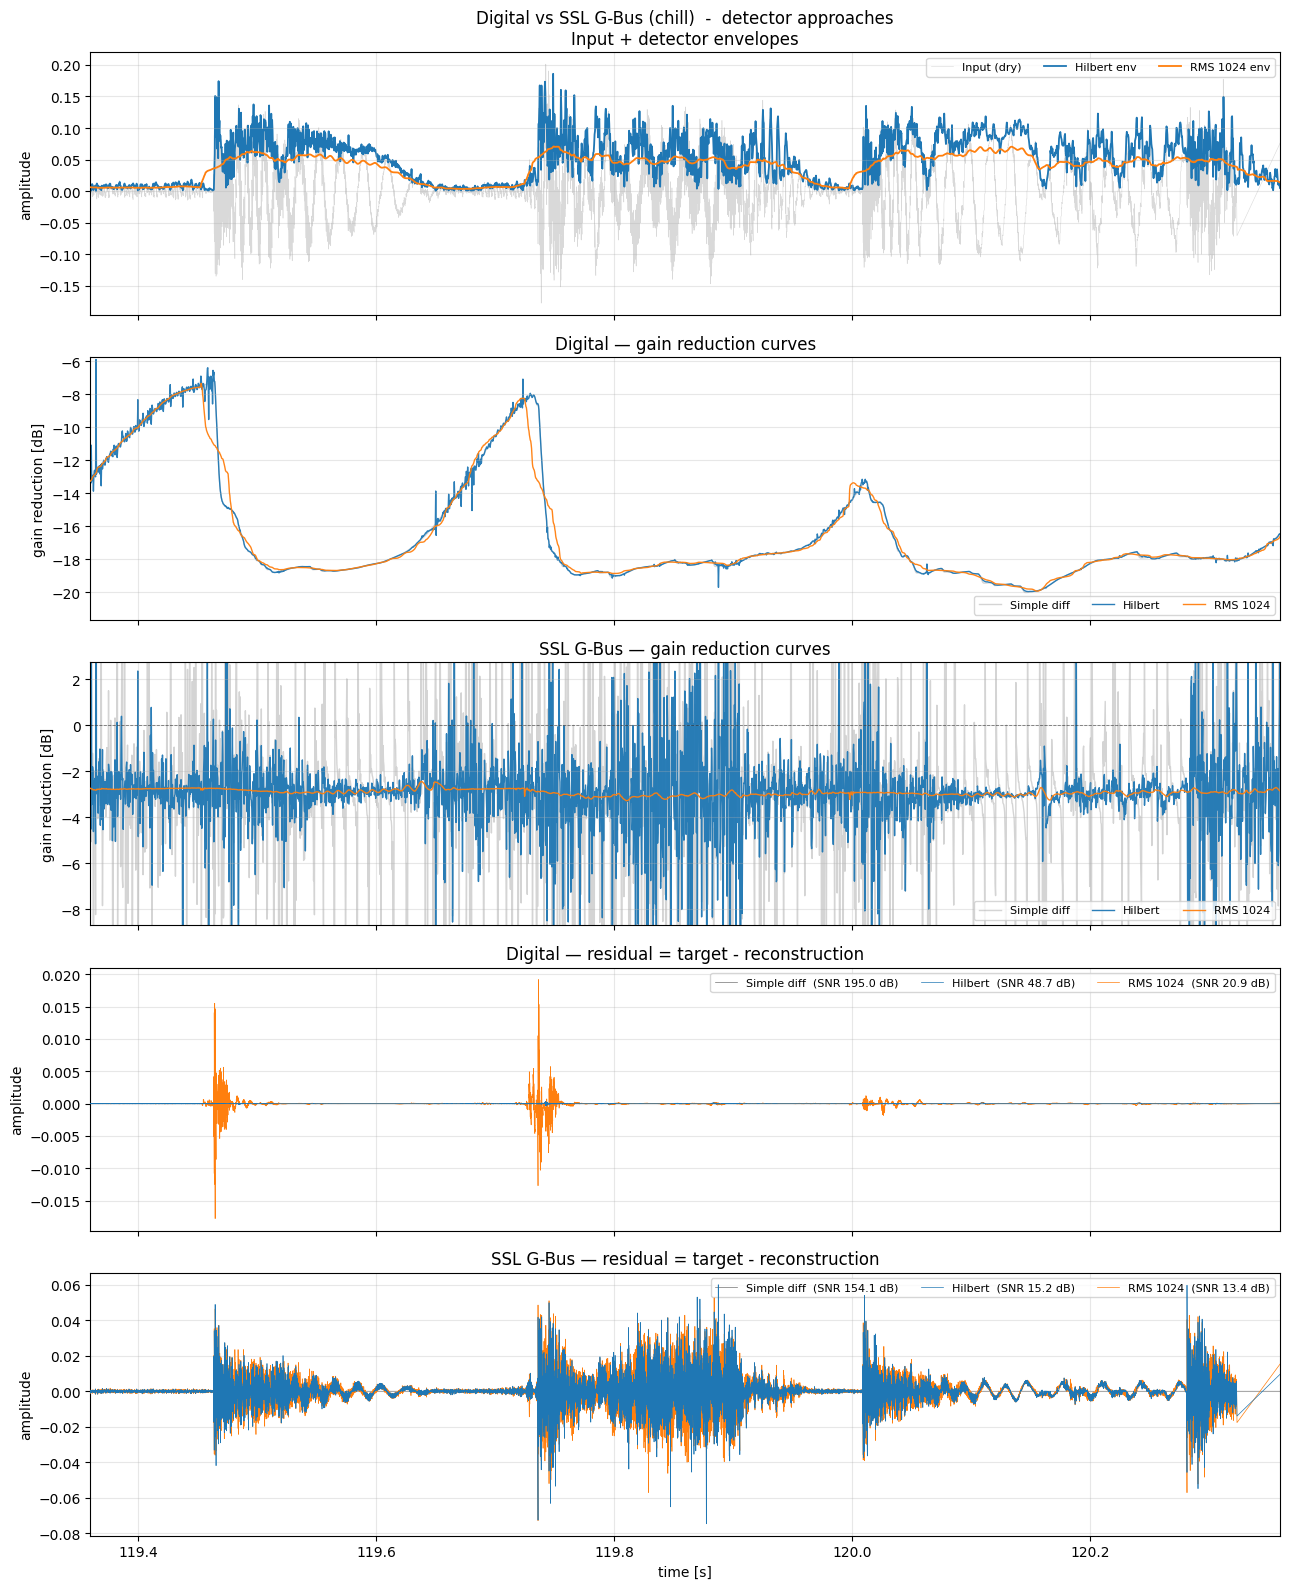

In [161]:
APPROACH_METHODS = ["Simple diff", "Hilbert", "RMS 1024"]
APPROACH_ENVS    = ["Hilbert", "RMS 1024"]

plot_compare("chill", APPROACH_METHODS, APPROACH_ENVS,
             "Digital vs SSL G-Bus (chill)  -  detector approaches")

In [162]:
play_residuals("chill", APPROACH_METHODS, "approaches")

CHILL  approaches  -  target + residuals
--- Digital  (make-up gain x16.6) ---
Digital  Target (wet)


Digital  Residual - Hilbert


Digital  Residual - RMS 1024


--- SSL (chill)  (make-up gain x5.9) ---
SSL (chill)  Target (wet)


SSL (chill)  Residual - Hilbert


SSL (chill)  Residual - RMS 1024


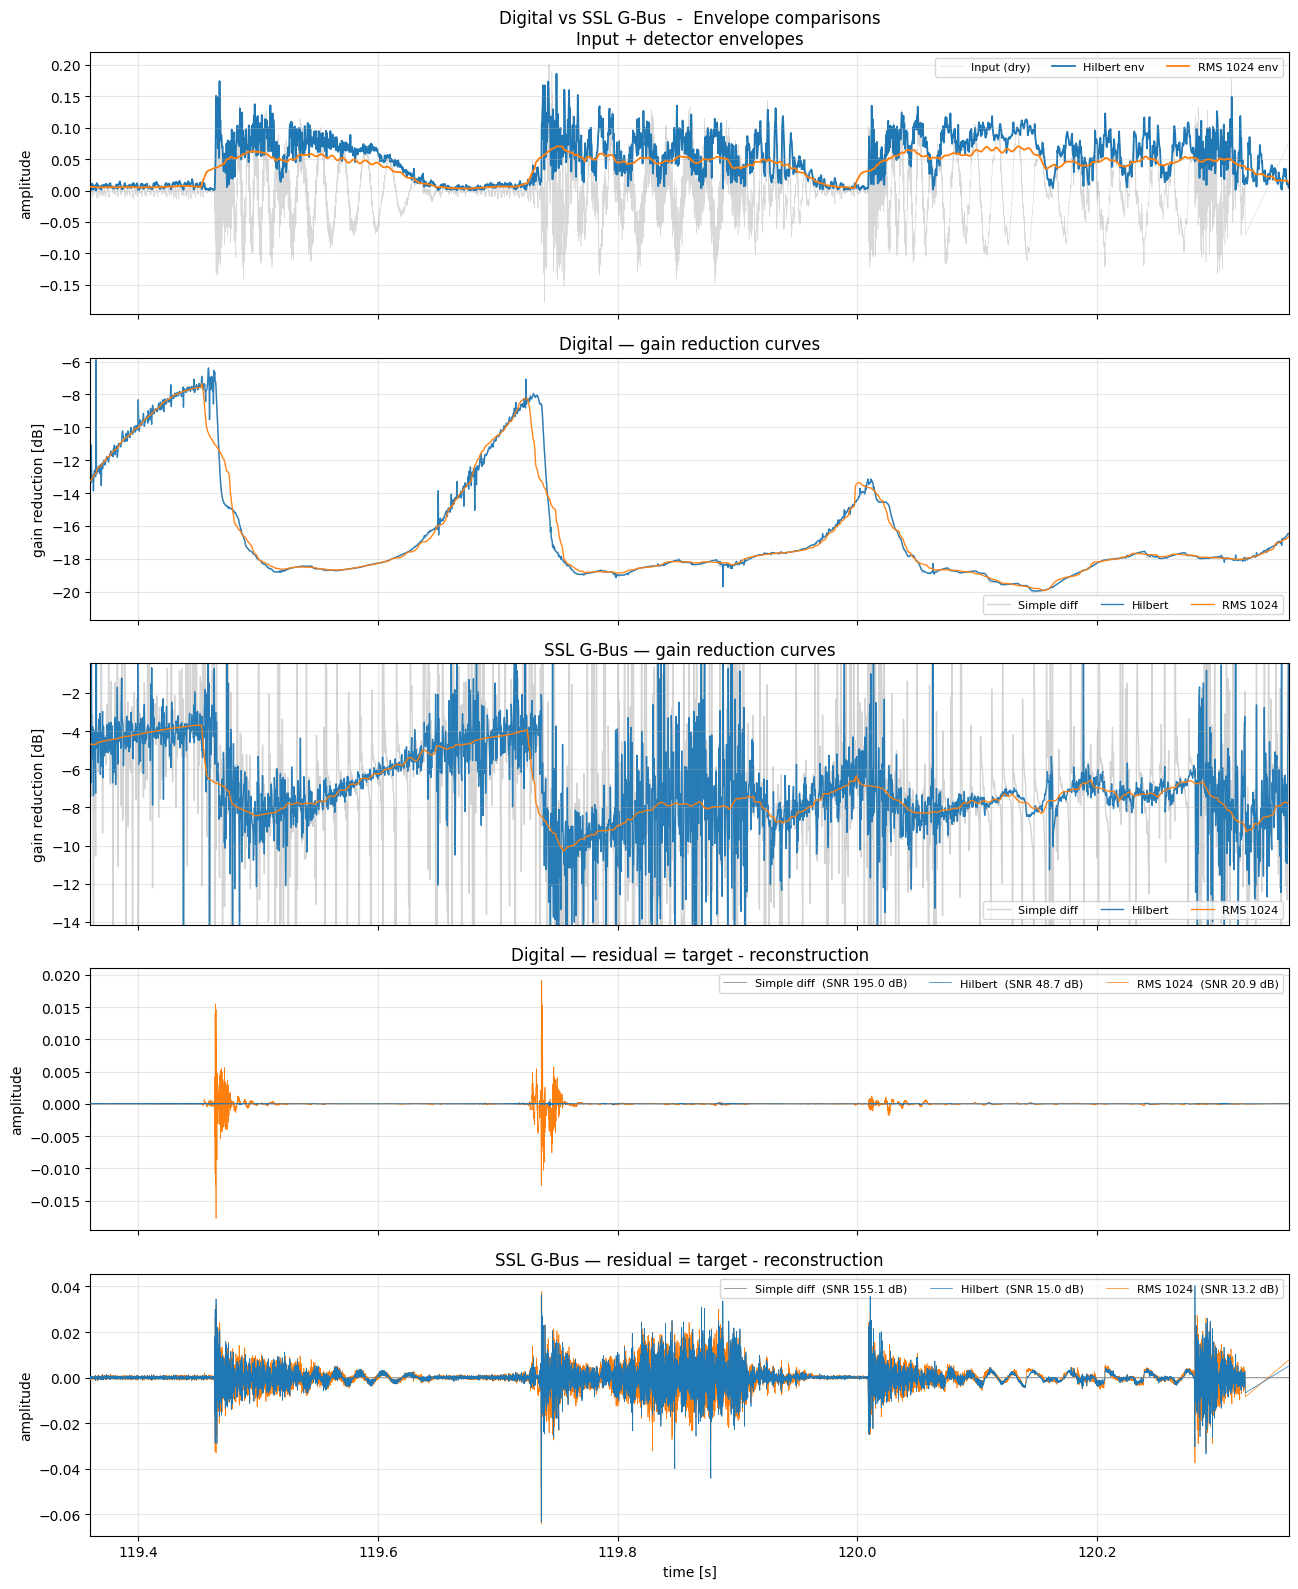

In [171]:
plot_compare("hard", APPROACH_METHODS, APPROACH_ENVS,
             "Digital vs SSL G-Bus  -  Envelope comparisons")

In [164]:
play_residuals("hard", APPROACH_METHODS, "approaches")

HARD  approaches  -  target + residuals
--- Digital  (make-up gain x16.6) ---
Digital  Target (wet)


Digital  Residual - Hilbert


Digital  Residual - RMS 1024


--- SSL (hard)  (make-up gain x11.2) ---
SSL (hard)  Target (wet)


SSL (hard)  Residual - Hilbert


SSL (hard)  Residual - RMS 1024


## 6. Version B — RMS window-size comparison

Same five panels, now contrasting RMS at **W = 4096 / 1024 / 256 / 64** (drawn
largest → smallest). Panel 1 shows the trade-off directly: the short window
tracks transients (and noise), the long window is smooth but smears onsets. The
effect is far more visible on the **Digital** GR/residual panels than on the
(nonlinearity-limited) SSL ones.

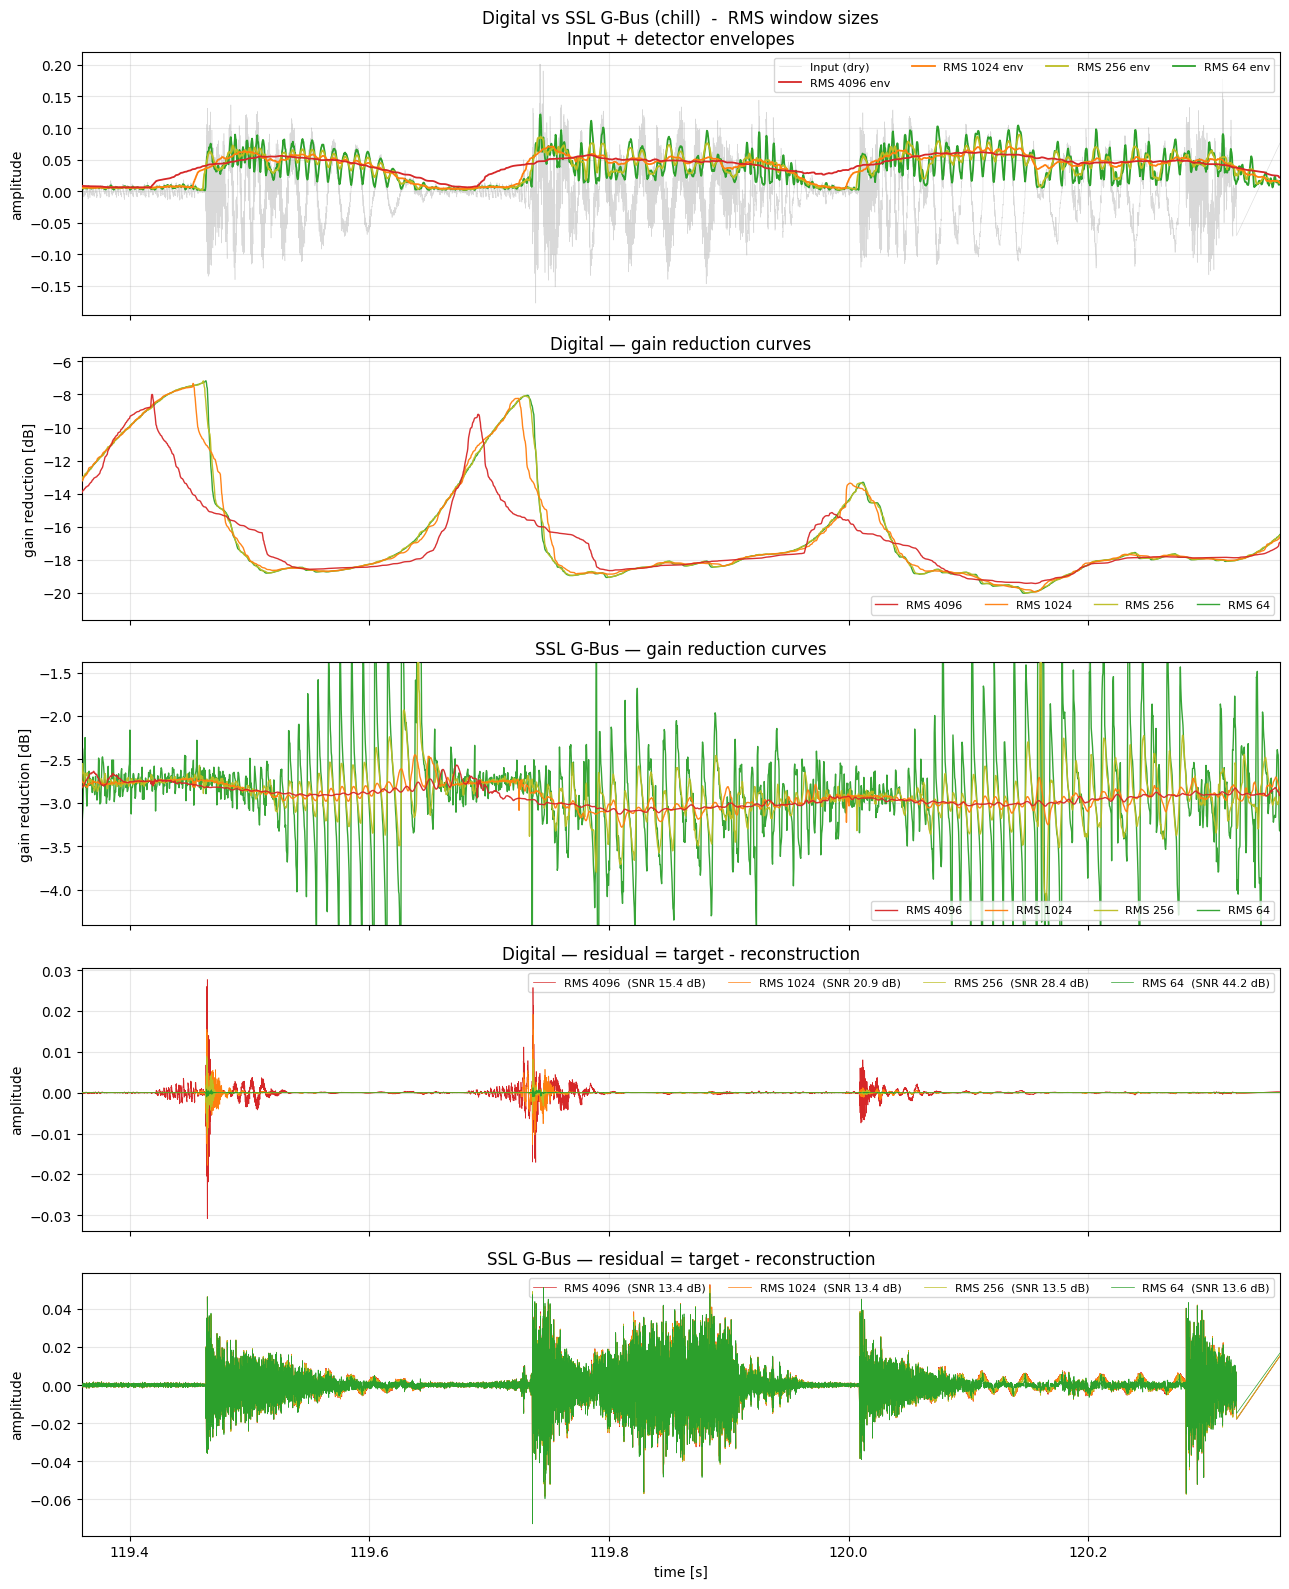

In [165]:
WINDOW_METHODS = [f"RMS {W}" for W in sorted(RMS_WINDOWS, reverse=True)]

plot_compare("chill", WINDOW_METHODS, WINDOW_METHODS,
             "Digital vs SSL G-Bus (chill)  -  RMS window sizes")

In [166]:
play_residuals("chill", WINDOW_METHODS, "windows")

CHILL  windows  -  target + residuals
--- Digital  (make-up gain x16.6) ---
Digital  Target (wet)


Digital  Residual - RMS 4096


Digital  Residual - RMS 1024


Digital  Residual - RMS 256


Digital  Residual - RMS 64


--- SSL (chill)  (make-up gain x5.9) ---
SSL (chill)  Target (wet)


SSL (chill)  Residual - RMS 4096


SSL (chill)  Residual - RMS 1024


SSL (chill)  Residual - RMS 256


SSL (chill)  Residual - RMS 64


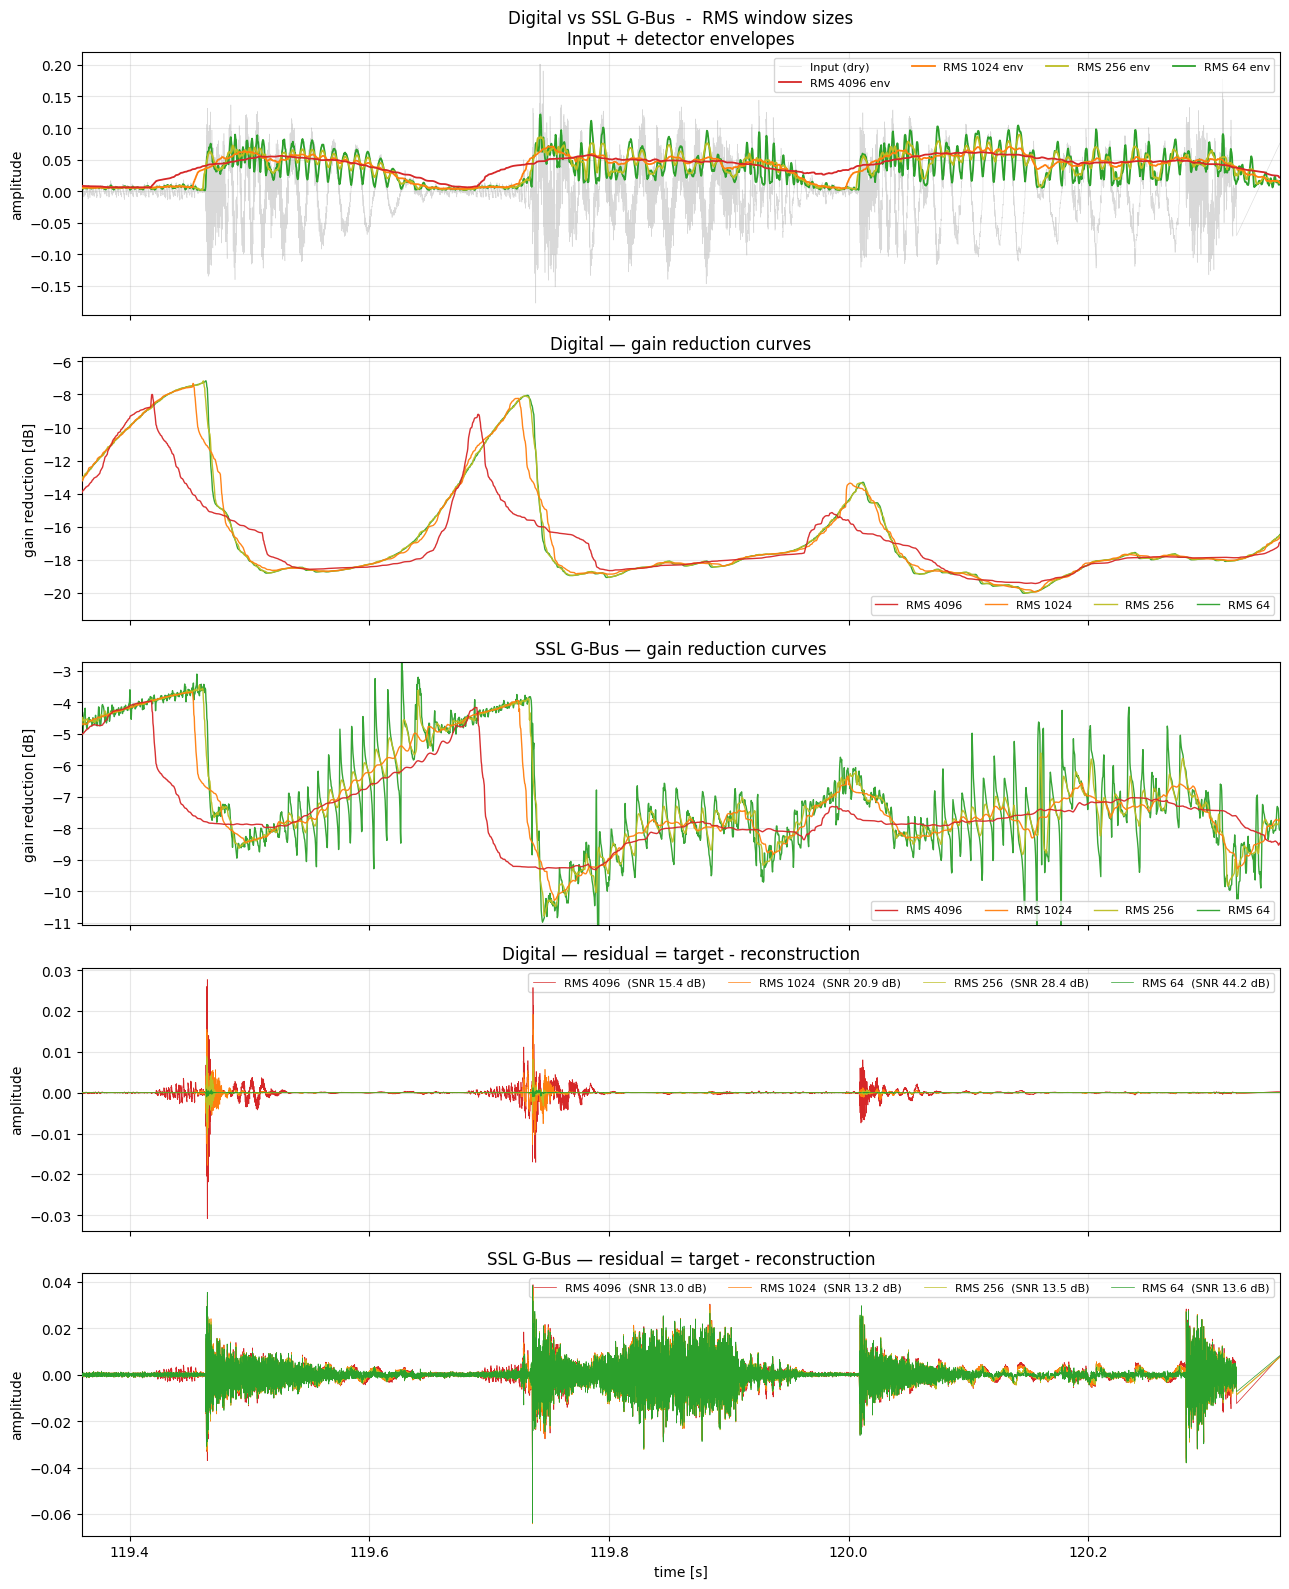

In [172]:
plot_compare("hard", WINDOW_METHODS, WINDOW_METHODS,
             "Digital vs SSL G-Bus  -  RMS window sizes")

In [168]:
play_residuals("hard", WINDOW_METHODS, "windows")

HARD  windows  -  target + residuals
--- Digital  (make-up gain x16.6) ---
Digital  Target (wet)


Digital  Residual - RMS 4096


Digital  Residual - RMS 1024


Digital  Residual - RMS 256


Digital  Residual - RMS 64


--- SSL (hard)  (make-up gain x11.2) ---
SSL (hard)  Target (wet)


SSL (hard)  Residual - RMS 4096


SSL (hard)  Residual - RMS 1024


SSL (hard)  Residual - RMS 256


SSL (hard)  Residual - RMS 64


### Zoom — waveform-level detail

The residual panels are dense over the full second. Pass `zoom=(start_s, dur_s)`
to zoom in on a single transient (the analysis itself is unchanged); here ~0.3 s
on the *hard* SSL setting.

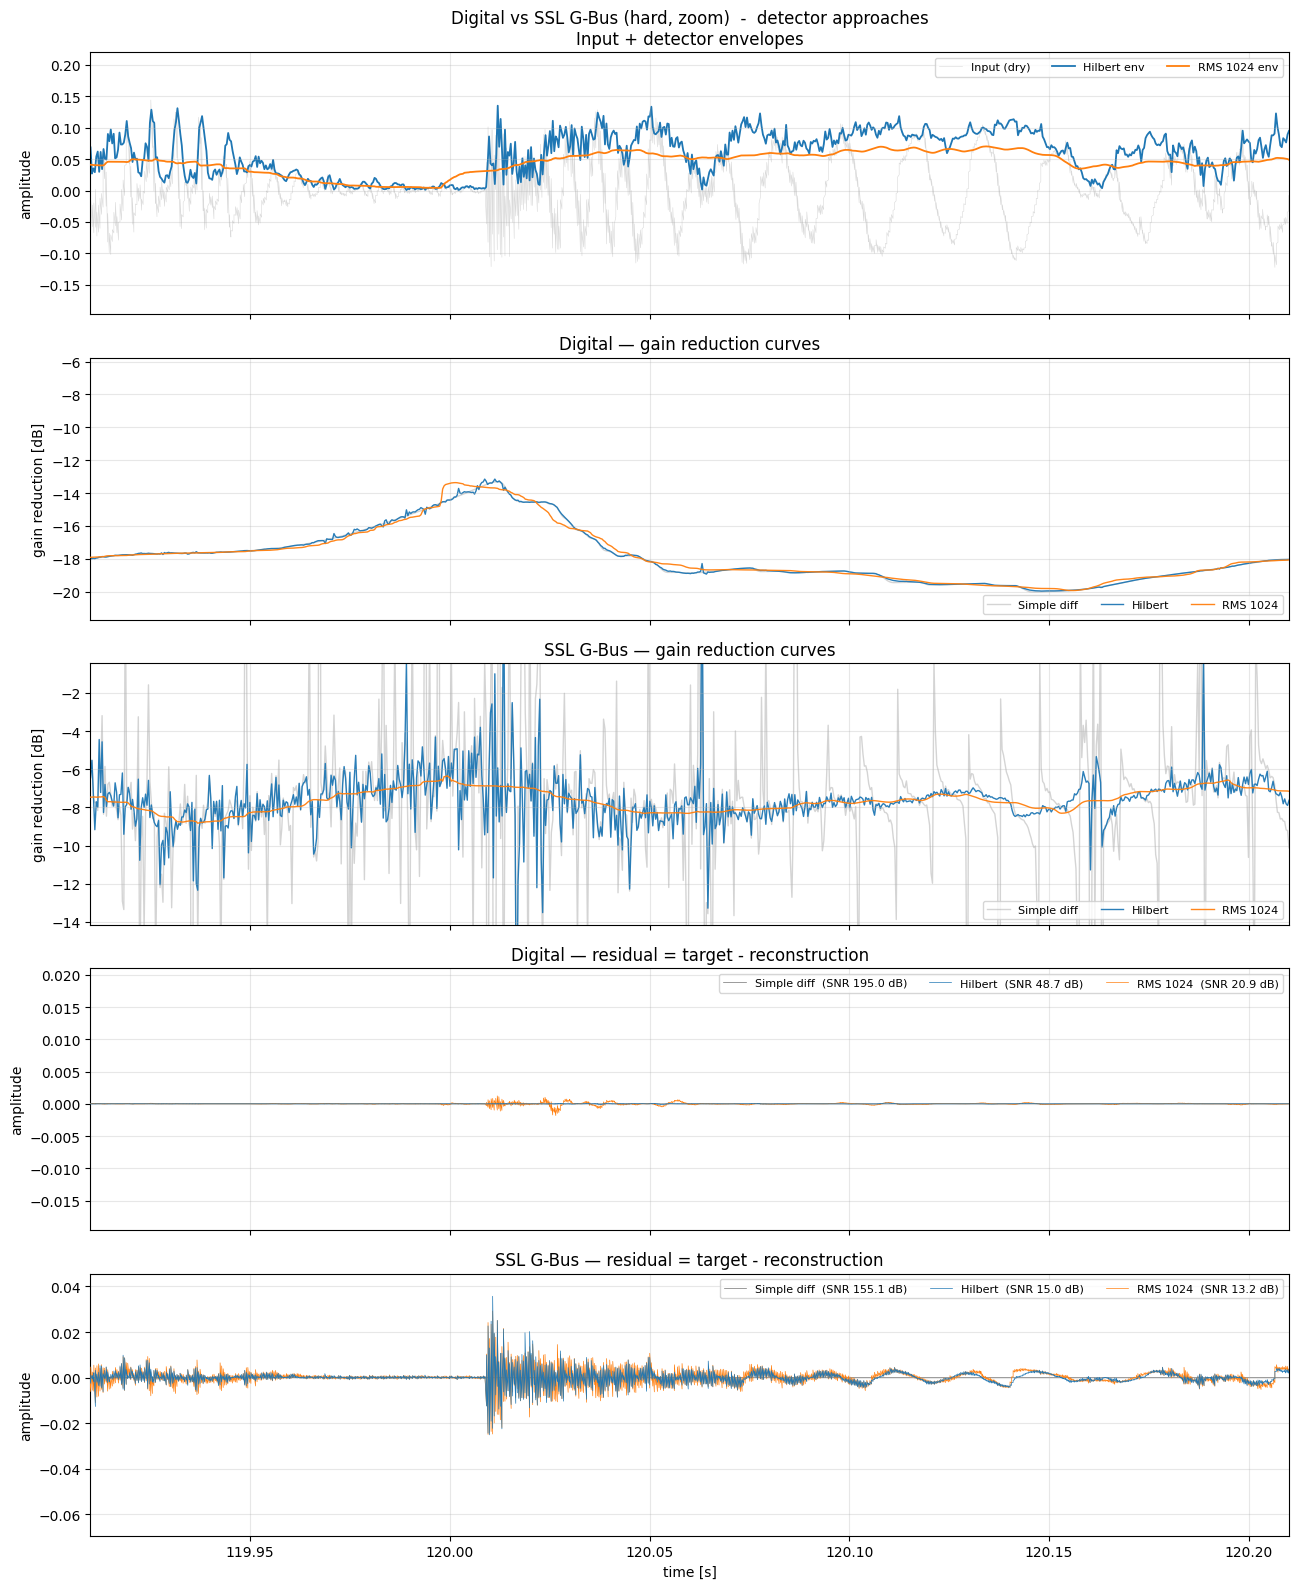

In [169]:
plot_compare("hard", APPROACH_METHODS, APPROACH_ENVS,
             "Digital vs SSL G-Bus (hard, zoom)  -  detector approaches",
             zoom=(SEG_START + 0.55, 0.3))